,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
 5   target_name        150 non-null    object 
dtypes: float64(4), int32(1), object(1)
memory usage: 6.6+ KB
None
------------------------------------------
We have no missing values, which is good. Let's continue with some graphs:
------------------------------------------


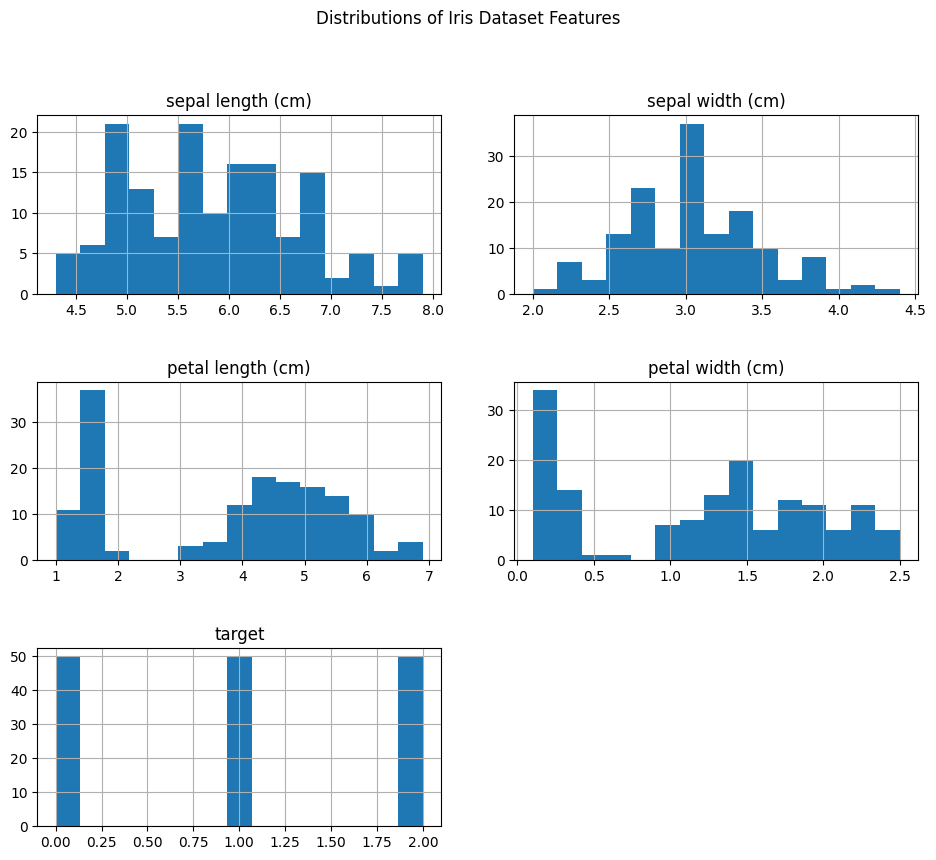

Petal length and width exhibit the most distinctive separation among species, making them critical for classification. Sepal measurements show more overlap and are less distinctive.
Also, each of our 3 classes contain 50 observations.


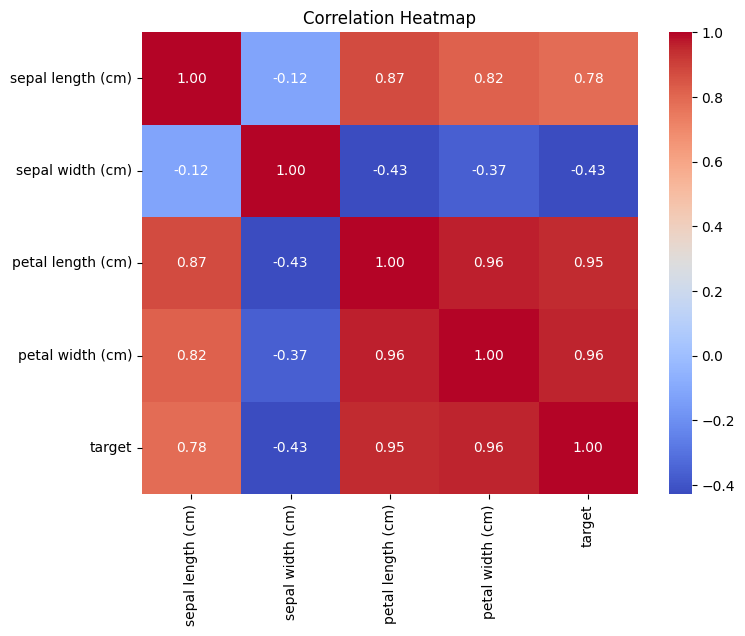

Since petal length and width are highly correlated between them and with the target, they vary together across species.
Probably if we scatter them we can see a clear separation between classes. Let's see:


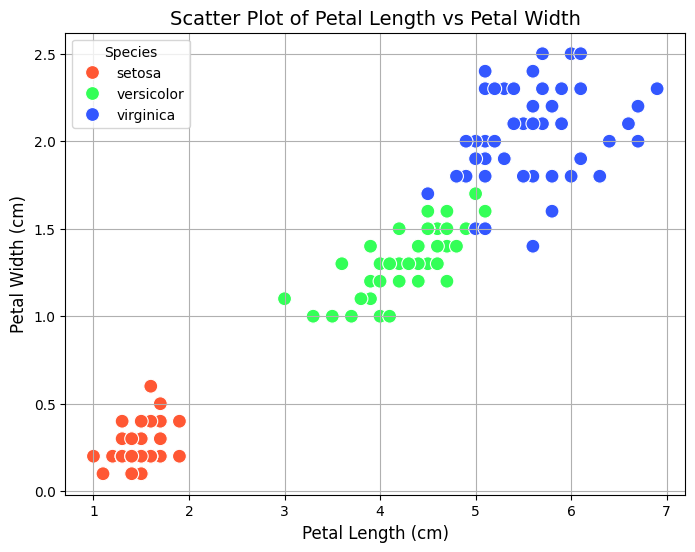

Our intuition was correct.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn import datasets
from scipy.stats import uniform

### DESCRIPTIVE STATISTICS ###

# Load the Iris dataset
iris = datasets.load_iris()

# Convert to Pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target column
df['target'] = iris.target
df['target_name'] = df['target'].map(lambda x: iris.target_names[x])

display(df)

print(df.info())

print("------------------------------------------")
print("We have no missing values, which is good. Let's continue with some graphs:")
print("------------------------------------------")

# Optional: Visualize distributions
df.hist(bins=15, figsize=(10, 9), layout=(3, 2))
plt.suptitle("Distributions of Iris Dataset Features")
plt.tight_layout(pad=3.0)
plt.show()

print("Petal length and width exhibit the most distinctive separation among species, making them critical for classification. Sepal measurements show more overlap and are less distinctive.")
print("Also, each of our 3 classes contain 50 observations.")

# Select numerical columns from your DataFrame
numerical_columns = df.select_dtypes(include=['number'])
# Create a heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(numerical_columns.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

print("Since petal length and width are highly correlated between them and with the target, they vary together across species.")
print("Probably if we scatter them we can see a clear separation between classes. Let's see:")

# Scatter plot for petal length and petal width with more distinct colors
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df['petal length (cm)'],
    y=df['petal width (cm)'],
    hue=df['target_name'],
    palette=['#FF5733', '#33FF57', '#3357FF'],  # Custom vivid and distinct colors
    s=100
)
plt.title("Scatter Plot of Petal Length vs Petal Width", fontsize=14)
plt.xlabel("Petal Length (cm)", fontsize=12)
plt.ylabel("Petal Width (cm)", fontsize=12)
plt.legend(title="Species", loc="upper left")
plt.grid(True)
plt.show()

print("Our intuition was correct.")

In [2]:
### Splitting the dataset into training and test sets ###

X = df.drop(['target', 'target_name'], axis=1)               # drop 'target' which will be used as our target variable, and 'target_name' which should not be included in our training and testing
y=df['target']

#Display our features for better understanding of your X
display(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=55)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [3]:
### Training a Decision Tree classifier, and using cross-validation to tune the hyperparameters ###

dtree1 = DecisionTreeClassifier(random_state=55)                    # Initialize the DecisionTreeClassifier

dtree_random_grid = {
    'max_depth': [2, 3, 5, 10],                                     # Reduced to smaller depths
    'min_samples_split': [5, 10, 15],                               # Larger splits to reduce overfitting
    'min_samples_leaf': [2, 5, 10],                                 # Larger leaf nodes to prevent deep splits
    'criterion': ['gini', 'entropy']                                # Test different impurity measures
}

dtree2 = RandomizedSearchCV(estimator=dtree1,                       # RandomizedSearchCV for parameter tuning
                            param_distributions=dtree_random_grid, 
                            cv=5,                                   # Use 5-folder cross-validation
                            verbose=2, 
                            n_jobs=-1, 
                            random_state=55)

dtree2.fit(X_train, y_train)                                        # Fit the model to training data

print("------------------------------------------")
print("Best Parameters for Decision Tree:", dtree2.best_params_)    # Print the best parameters for our Decision Tree
print("------------------------------------------")

dtree3 = DecisionTreeClassifier(                                    # Initialize a new Decision Tree Classifier with the best parameters
    max_depth=dtree2.best_params_['max_depth'],
    min_samples_split=dtree2.best_params_['min_samples_split'],
    min_samples_leaf=dtree2.best_params_['min_samples_leaf'],
    criterion=dtree2.best_params_['criterion'],
    random_state=55
)

dtree3.fit(X_train, y_train)                                        # Training the decision tree with the best parameters
dtree_test_preds = dtree3.predict(X_test)                           # Making predictions on the test set
dtree_train_preds = dtree3.predict(X_train)                         # Making predictions on the training set

#Decision Tree Results
print("Decision Tree Training Set Evaluation:\n")                   # Evaluate the model on the training set
print("Classification Report (Training):\n", classification_report(y_train, dtree_train_preds))
print("Confusion Matrix (Training):\n", confusion_matrix(y_train, dtree_train_preds))

print("------------------------------------------")

print("Decision Tree Test Set Evaluation:\n")                       # Evaluate the model on the test set
print("Classification Report (Test):\n", classification_report(y_test, dtree_test_preds))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, dtree_test_preds))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
------------------------------------------
Best Parameters for Decision Tree: {'min_samples_split': 15, 'min_samples_leaf': 2, 'max_depth': 3, 'criterion': 'gini'}
------------------------------------------
Decision Tree Training Set Evaluation:

Classification Report (Training):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.97      0.91      0.94        34
           2       0.92      0.97      0.95        36

    accuracy                           0.96       105
   macro avg       0.96      0.96      0.96       105
weighted avg       0.96      0.96      0.96       105

Confusion Matrix (Training):
 [[35  0  0]
 [ 0 31  3]
 [ 0  1 35]]
------------------------------------------
Decision Tree Test Set Evaluation:

Classification Report (Test):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00 

In [4]:
### Training a Random Forest classifier, and using cross-validation to tune the hyperparameters ###

rf1 = RandomForestClassifier(random_state=55)

n_estimators = [int(x) for x in np.linspace(start=50, stop=400, num=5)]                    # Reduce the number of trees
max_features = ['sqrt', 'log2']                                                            
max_depth = [int(x) for x in np.linspace(10, 100, num=5)]                                  # Shallower trees to avoid overfitting
max_depth.append(None)                                                                     # Allow unlimited depth as an option
min_samples_split = [2, 5, 10, 15]                                                         # Larger splits to generalize better
min_samples_leaf = [2, 5, 10, 15]                                                          # Larger leaves to reduce complexity
bootstrap = [True, False]                                                                  # Keep bootstrap sampling enabled for better generalization
rf_random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

rf2 = RandomizedSearchCV(estimator=rf1,                                                    # RandomizedSearchCV for parameter tuning
                            param_distributions=rf_random_grid, 
                            cv=5,                                                          # Use 5-folder cross-validation
                            verbose=2, 
                            n_jobs=-1,
                            random_state=55)

rf2.fit(X_train,y_train)                                                                   # Fit the model to training data

print("------------------------------------------")
print("Best Parameters for Random Forest:", rf2.best_params_)                              # Print the best parameters for our Random Forest
print("------------------------------------------")

rf3=RandomForestClassifier(                                                                # Initialize a new Random Forest Classifier with the best parameters
    n_estimators=rf2.best_params_['n_estimators'],
    max_features=rf2.best_params_['max_features'],                   
    max_depth=rf2.best_params_['max_depth'],
    min_samples_split=rf2.best_params_['min_samples_split'],
    min_samples_leaf=rf2.best_params_['min_samples_leaf'],
    bootstrap = rf2.best_params_['bootstrap'],
    random_state=55
)

rf3.fit(X_train,y_train)                                                                    # Training the Random Forest with the best parameters
rf_test_preds=rf3.predict(X_test)
rf_train_preds = rf3.predict(X_train)

# Random Forest Results
print("Random Forest Training Set Evaluation:\n")                                           # Evaluate the Random Forest model on the training set
print("Classification Report (Training):\n", classification_report(y_train, rf_train_preds))
print("Confusion Matrix (Training):\n", confusion_matrix(y_train, rf_train_preds))

print("------------------------------------------")

print("Random Forest Test Set Evaluation:\n")                                                # Evaluate the Random Forest model on the test set
print("Classification Report (Test):\n", classification_report(y_test, rf_test_preds))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, rf_test_preds))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
------------------------------------------
Best Parameters for Random Forest: {'n_estimators': 137, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 100, 'bootstrap': True}
------------------------------------------
Random Forest Training Set Evaluation:

Classification Report (Training):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.97      0.97      0.97        34
           2       0.97      0.97      0.97        36

    accuracy                           0.98       105
   macro avg       0.98      0.98      0.98       105
weighted avg       0.98      0.98      0.98       105

Confusion Matrix (Training):
 [[35  0  0]
 [ 0 33  1]
 [ 0  1 35]]
------------------------------------------
Random Forest Test Set Evaluation:

Classification Report (Test):
               precision    recall  f1-score   support



In [5]:
### Training a SVM classifier, and using cross-validation to tune the hyperparameters ###

# Standardize the data 
scaler = StandardScaler()                                         # Standardizing the features helps a lot because the Kernel requires the storage of the distances putting a burden on memory
X_train_standardized = scaler.fit_transform(X_train)
X_test_standardized = scaler.transform(X_test)

param_dist = {                                                    # Define the parameter distribution for kernel-based SVC
    'C': uniform(0.1, 1),                                         # Uniform distribution between 0.1 and 1
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],               # Different kernel options (Linear, Radial Basis Function, Polynomial, Sigmoid)
    'gamma': ['scale', 'auto'],                                   
    'degree': [2, 3, 4]                                           # Degree of polynomial kernel
}

svm_classifier = SVC()                                            # Creating a kernel-based Support Vector Machine classifier

# Use RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(svm_classifier, param_dist, n_iter=20, cv=5, scoring='accuracy', verbose=1, n_jobs=-1, random_state=55)
random_search.fit(X_train_standardized, y_train)

best_params_random = random_search.best_params_                    # Get the best hyperparameters
print("------------------------------------------")
print("Best Hyperparameters for SVC:", best_params_random)
print("------------------------------------------")

best_svc_random = random_search.best_estimator_                    # Make predictions on the test data using the best model from random search
svm_test_preds = best_svc_random.predict(X_test_standardized)
svm_train_preds = best_svc_random.predict(X_train_standardized)

# Random Forest Results
print("SVM Training Set Evaluation:\n")                  # Evaluate the Random Forest model on the training set
print("Classification Report (Training):\n", classification_report(y_train, svm_train_preds))
print("Confusion Matrix (Training):\n", confusion_matrix(y_train, svm_train_preds))

print("------------------------------------------")

print("SVM Evaluation:\n")                      # Evaluate the Random Forest model on the test set
print("Classification Report (Test):\n", classification_report(y_test, svm_test_preds))
print("Confusion Matrix (Test):\n", confusion_matrix(y_test, svm_test_preds))


Fitting 5 folds for each of 20 candidates, totalling 100 fits


------------------------------------------
Best Hyperparameters for SVC: {'C': 0.9626303770516396, 'degree': 4, 'gamma': 'scale', 'kernel': 'rbf'}
------------------------------------------
SVM Training Set Evaluation:

Classification Report (Training):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.94      0.97      0.96        34
           2       0.97      0.94      0.96        36

    accuracy                           0.97       105
   macro avg       0.97      0.97      0.97       105
weighted avg       0.97      0.97      0.97       105

Confusion Matrix (Training):
 [[35  0  0]
 [ 0 33  1]
 [ 0  2 34]]
------------------------------------------
SVM Evaluation:

Classification Report (Test):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.88      0.93        16
           2       0.88      1.00      0.93

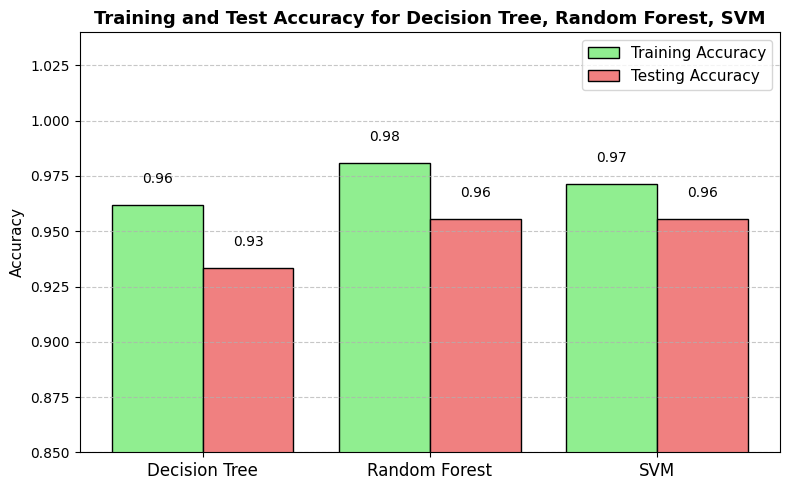

In [6]:
### Plotting the accuracy scores for the Training and Test Sets for each Classifier

# Store the accuracy scores of each classifier to use them in the plot
dt_train_accuracy = accuracy_score(y_train, dtree_train_preds)
dt_test_accuracy = accuracy_score(y_test, dtree_test_preds)

rf_train_accuracy = accuracy_score(y_train, rf_train_preds)
rf_test_accuracy = accuracy_score(y_test, rf_test_preds)

svm_train_accuracy = accuracy_score(y_train, svm_train_preds)
svm_test_accuracy = accuracy_score(y_test, svm_test_preds)

accuracies = {
    "Model": ["Decision Tree", "Random Forest", "SVM"],
    "Training Accuracy": [dt_train_accuracy, rf_train_accuracy, svm_train_accuracy],
    "Testing Accuracy": [dt_test_accuracy, rf_test_accuracy, svm_test_accuracy],
}

accuracy_df = pd.DataFrame(accuracies)

plt.figure(figsize=(8, 5))
x = range(len(accuracy_df["Model"]))

plt.bar(x, accuracy_df["Training Accuracy"], width=0.4, label="Training Accuracy", align='center', color='lightgreen', edgecolor='black')
plt.bar([i + 0.4 for i in x], accuracy_df["Testing Accuracy"], width=0.4, label="Testing Accuracy", align='center', color='lightcoral', edgecolor='black')

for i, v in enumerate(accuracy_df["Training Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=10)
for i, v in enumerate(accuracy_df["Testing Accuracy"]):
    plt.text(i + 0.4, v + 0.01, f"{v:.2f}", ha='center', fontsize=10)

plt.xticks([i + 0.2 for i in x], accuracy_df["Model"], fontsize=12)
plt.ylabel("Accuracy", fontsize=11)
plt.title("Training and Test Accuracy for Decision Tree, Random Forest, SVM", fontsize=13, fontweight='bold')
plt.ylim(0.85, 1.04)  
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.tight_layout()
plt.show()



It can be seen that the Random Forest and the Support Vector Machine predict more accurately both in the Training and Testing sets, with the Random Forest slightly beating the SVM in the Training set. Their high accuracy scores indicate a very good prediction accuracy in our Iris dataset.
The Decision Tree classifer performs slightly worse than the Random Forest and the SVM, however, it also shows a high prediction accuracy of 96% and 93% for the training and testing sets, respectively.
In general, it seems that all of our Classifiers performed very well, which might occur because of our small dataset and from the fact that we had no missing values, and some clearly separable classes.
Random Forest and SVM classifiers performed slightly better than the Decision Tree, mostly in the Testing set, which makes sense due to their ability of better data generalization and robustness to overfitting.